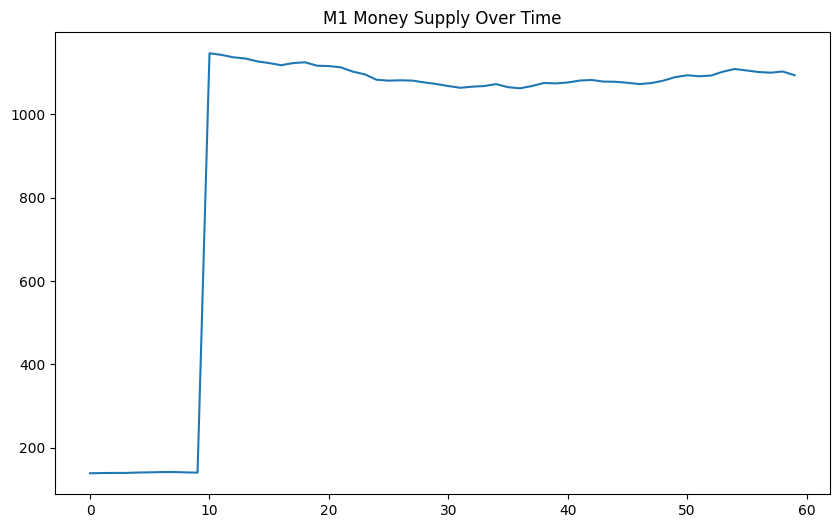

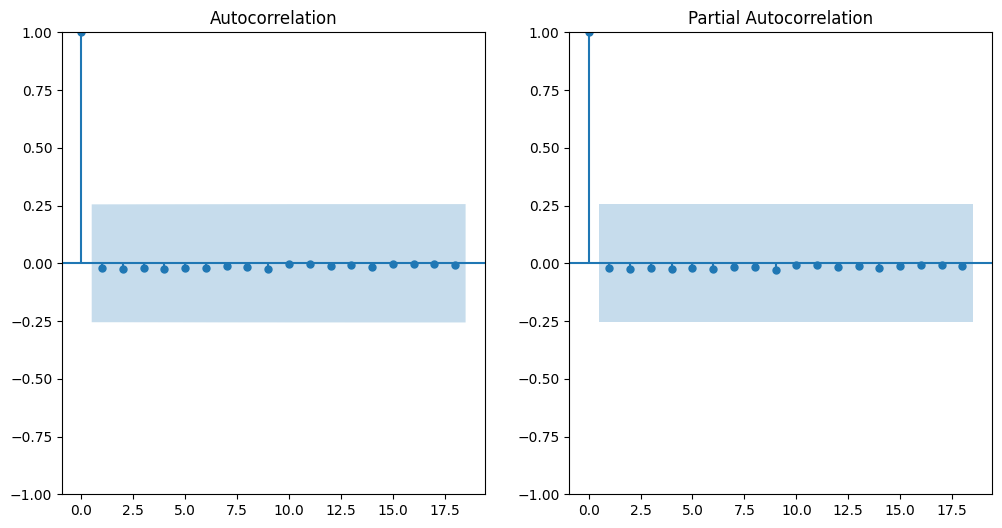

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   60
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -371.349
Date:                Fri, 02 May 2025   AIC                            748.698
Time:                        17:47:15   BIC                            754.931
Sample:                             0   HQIC                           751.131
                                 - 60                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9403     32.010      0.029      0.977     -61.798      63.678
ma.L1         -0.9462     30.009     -0.032      0.975     -59.762      57.870
sigma2      1.716e+04   1294.363     13.255      0.0

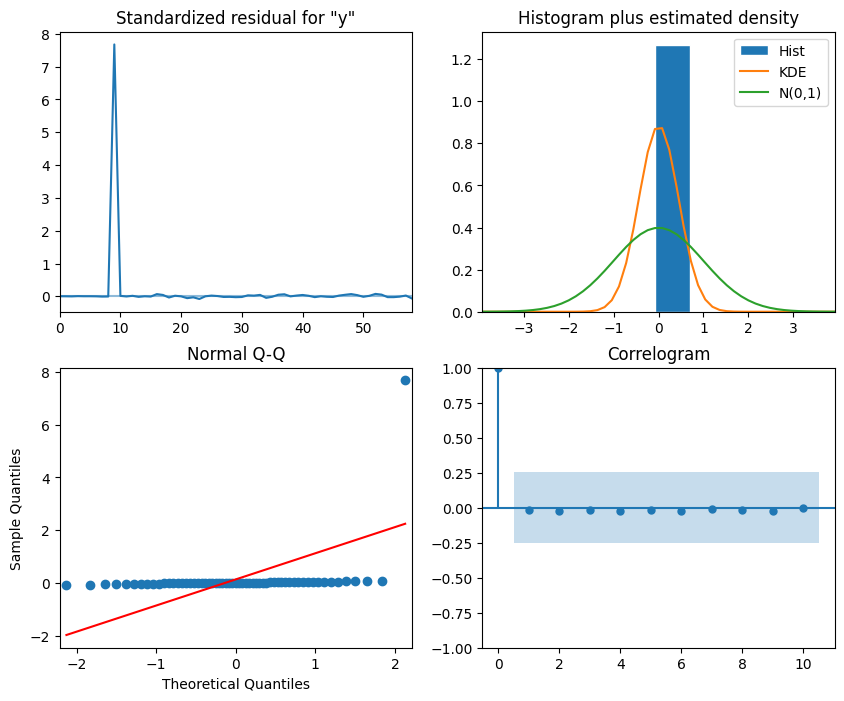

Forecasted values for next 12 periods:
 60    1093.069639
61    1092.702576
62    1092.357419
63    1092.032863
64    1091.727677
65    1091.440706
66    1091.170861
67    1090.917122
68    1090.678526
69    1090.454170
70    1090.243205
71    1090.044830
Name: predicted_mean, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load data (assuming it's in a list from Table 21.1)
data = [138.89, 139.39, 139.74, 139.69, 140.68, 141.17, 141.7, 141.9, 141.01, 140.47,
        # ... (continue with all 489 values) ...
        1146.1, 1142.27, 1136.43, 1133.55, 1126.73, 1122.58, 1117.53, 1122.59, 1124.52, 1116.3, 1115.47, 1112.34, 1102.18, 1095.61, 1082.56, 1080.49, 1081.34, 1080.52, 1076.2, 1072.42, 1067.45, 1063.37, 1065.99, 1067.57, 1072.08, 1064.82, 1062.06, 1067.53, 1074.87, 1073.81, 1076.02, 1080.65, 1082.09, 1078.17, 1077.78, 1075.37, 1072.21, 1074.65, 1080.4, 1088.96, 1093.35, 1091, 1092.65, 1102.01, 1108.4, 1104.75, 1101.11, 1099.53, 1102.4, 1093.46]

# Create time series
series = pd.Series(data)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(series)
plt.title('M1 Money Supply Over Time')
plt.show()

# Differencing for stationarity (e.g., first difference)
series_diff = series.diff().dropna()

# ACF and PACF plots
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(series_diff, ax=plt.gca())
plt.subplot(122)
plot_pacf(series_diff, ax=plt.gca())
plt.show()

# Fit ARIMA model (example: ARIMA(1,1,1))
model = ARIMA(series, order=(1, 1, 1))
results = model.fit()

# Summary
print(results.summary())

# Diagnostics
results.plot_diagnostics(figsize=(10, 8))
plt.show()

# Forecasting
forecast = results.forecast(steps=12)
print("Forecasted values for next 12 periods:\n", forecast)